In [50]:
import torch
torch.set_float32_matmul_precision("high")
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt
import shapiq 
import src

### load model

In [51]:
from types import SimpleNamespace
import numpy as np
import clip


class OpenAIClipBatch(dict):
    def tokens(self):
        n_text_players = int(self["input_ids"].shape[1]) - 2
        return ["<s>"] + [f"tok_{i}" for i in range(n_text_players)] + ["</s>"]


class OpenAICLIPProcessorAdapter:
    def __init__(self, preprocess, context_length=77):
        self.preprocess = preprocess
        self.context_length = int(context_length)
        self.image_processor = SimpleNamespace(
            image_mean=(0.48145466, 0.4578275, 0.40821073),
            image_std=(0.26862954, 0.26130258, 0.27577711),
        )

    @staticmethod
    def _as_list(value):
        return list(value) if isinstance(value, (list, tuple)) else [value]

    def __call__(self, images, text, return_tensors="pt", padding=True, max_length=None):
        images = self._as_list(images)
        texts = self._as_list(text)
        pixel_values = torch.stack([
            self.preprocess(
                img.convert("RGB") if hasattr(img, "convert")
                else Image.fromarray(np.asarray(img)).convert("RGB")
            )
            for img in images
        ])
        full_tokens = clip.tokenize(texts, context_length=self.context_length, truncate=True)
        lengths = []
        for row in full_tokens:
            nonzero = torch.nonzero(row, as_tuple=False).flatten()
            lengths.append(int(nonzero[-1].item()) + 1 if len(nonzero) else 2)
        short_len = max(lengths)
        input_ids = torch.zeros((len(texts), short_len), dtype=torch.long)
        attention_mask = torch.zeros((len(texts), short_len), dtype=torch.long)
        for i, length in enumerate(lengths):
            input_ids[i, :length] = full_tokens[i, :length]
            attention_mask[i, :length] = 1
        return OpenAIClipBatch(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
        )


class OpenAICLIPModelAdapter(torch.nn.Module):
    def __init__(self, clip_model, name_or_path):
        super().__init__()
        self.clip_model = clip_model
        self.name_or_path = name_or_path
        self.context_length = int(getattr(clip_model, "context_length", 77))
        image_size = int(getattr(clip_model.visual, "input_resolution", 224))
        self.config = SimpleNamespace(
            model_type="clip",
            vision_config=SimpleNamespace(image_size=image_size, num_channels=3),
        )
        self.vision_model = SimpleNamespace()

    def forward(self, pixel_values, input_ids, attention_mask):
        token_ids = input_ids.clone()
        token_ids = token_ids.masked_fill(attention_mask.to(token_ids.device) == 0, 0)
        if token_ids.shape[1] < self.context_length:
            pad = torch.zeros(
                (token_ids.shape[0], self.context_length - token_ids.shape[1]),
                dtype=token_ids.dtype,
                device=token_ids.device,
            )
            token_ids = torch.cat([token_ids, pad], dim=1)
        elif token_ids.shape[1] > self.context_length:
            token_ids = token_ids[:, :self.context_length]
        logits_per_image, logits_per_text = self.clip_model(pixel_values, token_ids)
        return SimpleNamespace(
            logits_per_image=logits_per_image,
            logits_per_text=logits_per_text,
        )

In [52]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.to('cuda')
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# CLIP-ResNet + SLIC integration check:
# run the OpenAI CLIP adapter cell above first, then uncomment one model pair below.

# raw_model, preprocess = clip.load("RN50", device="cuda", jit=False)
# model = OpenAICLIPModelAdapter(raw_model, "openai/clip-rn50").to("cuda").eval()
# processor = OpenAICLIPProcessorAdapter(preprocess, context_length=model.context_length)

# raw_model, preprocess = clip.load("RN101", device="cuda", jit=False)
# model = OpenAICLIPModelAdapter(raw_model, "openai/clip-rn101").to("cuda").eval()
# processor = OpenAICLIPProcessorAdapter(preprocess, context_length=model.context_length)

raw_model, preprocess = clip.load("RN50x4", device="cuda", jit=False)
model = OpenAICLIPModelAdapter(raw_model, "openai/clip-rn50x4").to("cuda").eval()
processor = OpenAICLIPProcessorAdapter(preprocess, context_length=model.context_length)

### load data

In [3]:
input_text = "black dog next to a yellow hydrant"
input_image = Image.open("assets/dog_and_hydrant.png")

### define game

In [53]:
from ImputerFactory import ImageImputerFactory
from Game.game_huggingface import VisionLanguageGame

factory = ImageImputerFactory()
# imputer = factory.build(model, processor, input_image, input_text)
imputer = factory.build(model, processor, input_image, input_text, segmenter="slic", masker="crossmodal")
game = VisionLanguageGame(imputer, batch_size=64)
n_players_image = game.n_players_image
n_players_text = game.n_players_text

### define approximator

In [54]:
fixlip = src.fixlip.FIxLIP(
    n_players_image=n_players_image,
    n_players_text=n_players_text, 
    max_order=2,
    p=0.5, # weight
    mode="banzhaf",
    random_state=0
)

### compute explanation

In [55]:
src.utils.set_seed(0)
interaction_values = fixlip.approximate_crossmodal(game, budget=2**19)

### save explanation

In [56]:
# interaction_values.save("results/dog_and_hydrant_fixlip.pkl")

### visualize explanation

In [57]:
# interaction_values = shapiq.InteractionValues.load("results/dog_and_hydrant_fixlip.pkl")
print(interaction_values)

InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=True, estimation_budget=524161,
    n_players=39, baseline_value=1.0593558510482157,
    Top 10 interactions:
        (37, 38): 5.3844828135858265
        (6, 37): 2.919525383964884
        (32,): 2.190155482910765
        (33, 34): 1.6073900562907342
        (36,): 1.549552334820049
        (34,): -1.7371795357352715
        (31, 32): -1.7955041732628991
        (38,): -1.995378821888907
        (24, 27): -2.116123400620975
        (37,): -2.812153301238699
)


In [58]:
def denormalize(img, mean, std):
    return img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
image_mean = (0.48145466, 0.4578275, 0.40821073)
image_std = (0.26862954, 0.26130258, 0.27577711)

In [59]:
if getattr(game._imputer.config, "segmenter", None) == "slic":
    text_tokens = input_text.split()
else:
    text_tokens = game.inputs.tokens()
    text_tokens = text_tokens[1:-1]
    text_tokens = [token.replace('</w>', '') for token in text_tokens]
    assert len(text_tokens) == game.n_players_text
players_text = list(range(game.n_players_image, game.n_players))
assert game.n_players == interaction_values.n_players == max(players_text) + 1
input_image_processed = game.inputs['pixel_values'].squeeze(0)
input_image_denormalized = src.utils.denormalize(
    input_image_processed, 
    game.processor.image_processor.image_mean, 
    game.processor.image_processor.image_std
).permute(1, 2, 0).numpy()

### FIxLIP

<string>:12: UserWarning: Index FWBII is not a valid index as defined in {'Moebius', 'EGV', 'STII', 'ELC', 'BII', 'k-SII', 'FSII', 'BV', 'EC', 'FBII', 'SV', 'SGV', 'IGV', 'JointSV', 'SII', 'CHII', 'Co-Moebius', 'kADD-SHAP', 'BGV', 'CHGV'}. This might lead to unexpected behavior.


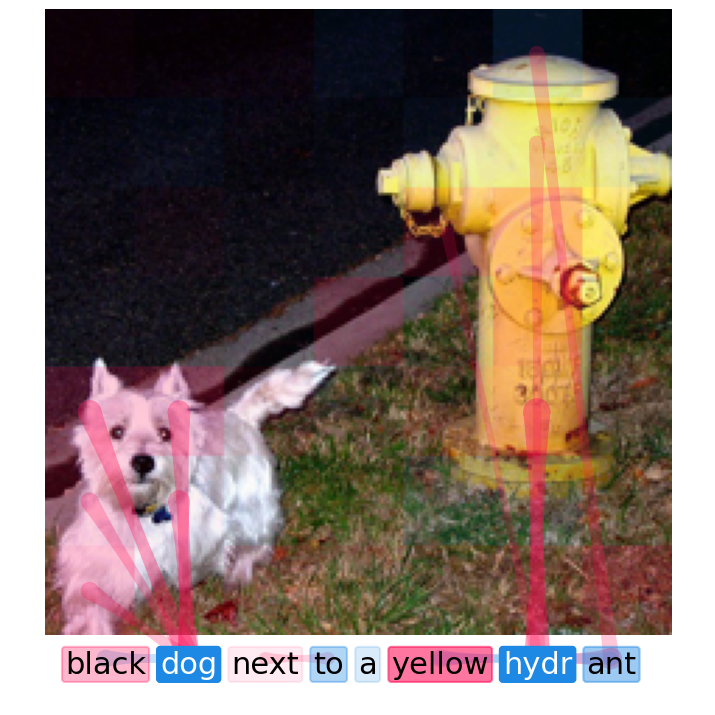

In [10]:
src.plot.plot_image_and_text_together(
    img=input_image_denormalized,
    text=text_tokens,
    image_players=list(range(n_players_image)),
    iv=interaction_values,
    plot_interactions=True,
    top_k=14,
    normalize_jointly=True,
    figsize=(7, 7),
    fontsize=22,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    show=False,
    max_value=4
)
plt.tight_layout(pad=0.15)
# plt.savefig("dog_and_hydrant_fixlip.pdf")

### GAME

In [11]:
iv_game = shapiq.InteractionValues.load("results/dog_and_hydrant_game.pkl")
print(iv_game)

InteractionValues(
    index=, max_order=1, min_order=0, estimated=True, estimation_budget=None,
    n_players=57, baseline_value=0,
    Top 10 interactions:
        (56,): 0.1417236328125
        (12,): 0.02716064453125
        (18,): 0.02264404296875
        (26,): 0.016082763671875
        (19,): 0.012054443359375
        (40,): 0.00997161865234375
        (33,): 0.00981903076171875
        (20,): 0.00688934326171875
        (55,): 0.0054931640625
        (5,): 0.005481719970703125
)


<string>:12: UserWarning: Index  is not a valid index as defined in {'JointSV', 'SII', 'STII', 'IGV', 'Co-Moebius', 'FBII', 'ELC', 'EGV', 'FSII', 'SGV', 'BGV', 'BV', 'Moebius', 'BII', 'kADD-SHAP', 'CHGV', 'k-SII', 'SV', 'EC', 'CHII'}. This might lead to unexpected behavior.


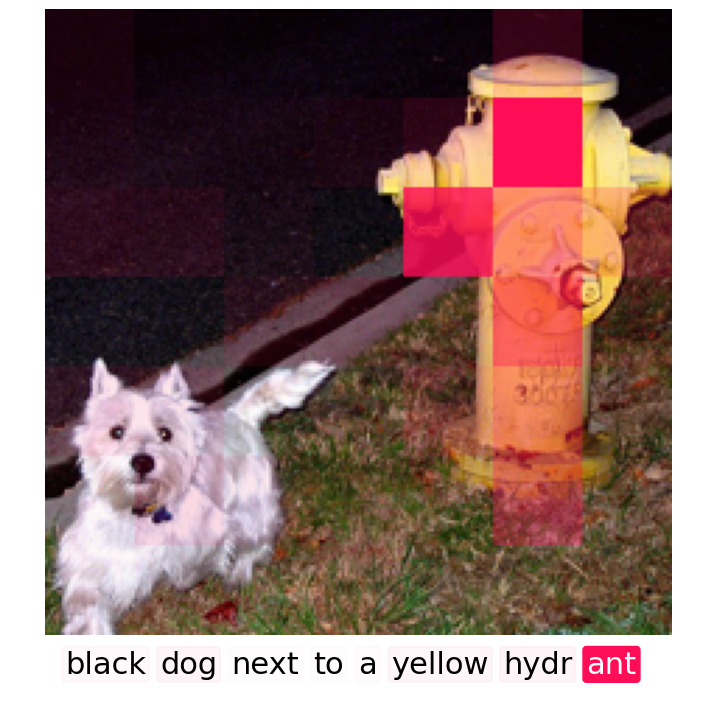

In [12]:
src.plot.plot_image_and_text_together(
    img=input_image_denormalized,
    text=text_tokens,
    image_players=list(range(n_players_image)),
    iv=iv_game,
    plot_interactions=False,
    normalize_jointly=False,
    figsize=(7, 7),
    fontsize=22,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    show=False,
)
plt.tight_layout(pad=0.15)
# plt.savefig("dog_and_hydrant_game.pdf")

### Grad-ECLIP

In [18]:
iv_gradeclip = shapiq.InteractionValues.load("results/dog_and_hydrant_gradeclip.pkl")
print(iv_gradeclip)

InteractionValues(
    index=, max_order=1, min_order=0, estimated=True, estimation_budget=None,
    n_players=57, baseline_value=0,
    Top 10 interactions:
        (18,): 0.299560546875
        (12,): 0.255126953125
        (20,): 0.243408203125
        (56,): 0.212890625
        (11,): 0.1727294921875
        (40,): 0.155517578125
        (33,): 0.1522216796875
        (50,): 0.1451416015625
        (19,): 0.138671875
        (36,): 0.1378173828125
)


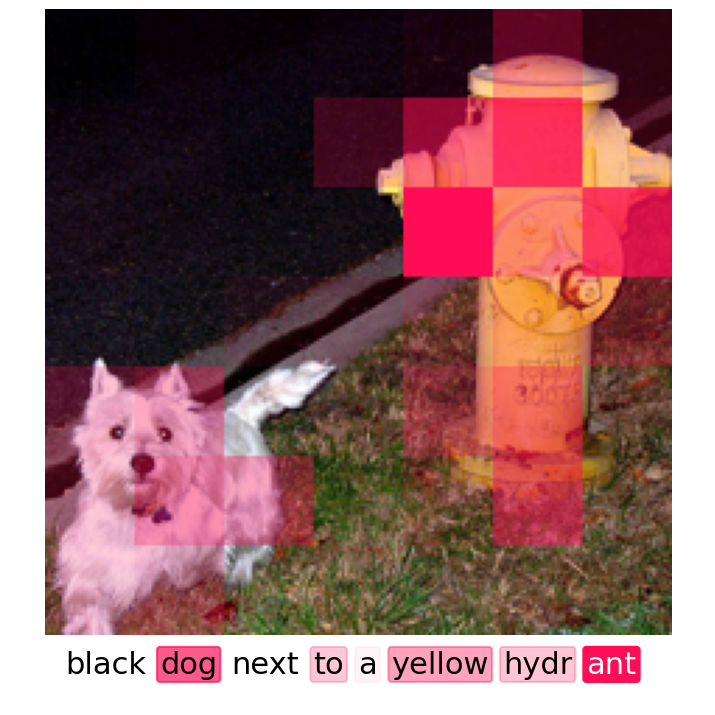

In [19]:
src.plot.plot_image_and_text_together(
    img=input_image_denormalized,
    text=text_tokens,
    image_players=list(range(n_players_image)),
    iv=iv_gradeclip,
    plot_interactions=False,
    normalize_jointly=False,
    figsize=(7, 7),
    fontsize=22,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    show=False,
)
plt.tight_layout(pad=0.15)
# plt.savefig("dog_and_hydrant_gradeclip.pdf")

### exCLIP

In [20]:
iv_exclip = shapiq.InteractionValues.load("results/dog_and_hydrant_exclip.pkl")
print(iv_exclip)

InteractionValues(
    index=xclip, max_order=2, min_order=0, estimated=True, estimation_budget=None,
    n_players=57, baseline_value=0,
    Top 10 interactions:
        (18, 56): 0.0062236059457063675
        (20, 56): 0.005851599387824535
        (12, 56): 0.005055509507656097
        (33, 56): 0.0035493001341819763
        (11, 56): 0.0033396072685718536
        (40, 56): 0.0032137271482497454
        (32, 56): 0.0023629264906048775
        (29, 56): -0.0022027851082384586
        (28, 56): -0.002554086036980152
        (30, 56): -0.0028323226142674685
)


<string>:12: UserWarning: Index xclip is not a valid index as defined in {'EC', 'Co-Moebius', 'STII', 'SV', 'FSII', 'BGV', 'FBII', 'JointSV', 'CHII', 'BII', 'EGV', 'SII', 'CHGV', 'Moebius', 'ELC', 'k-SII', 'kADD-SHAP', 'IGV', 'BV', 'SGV'}. This might lead to unexpected behavior.


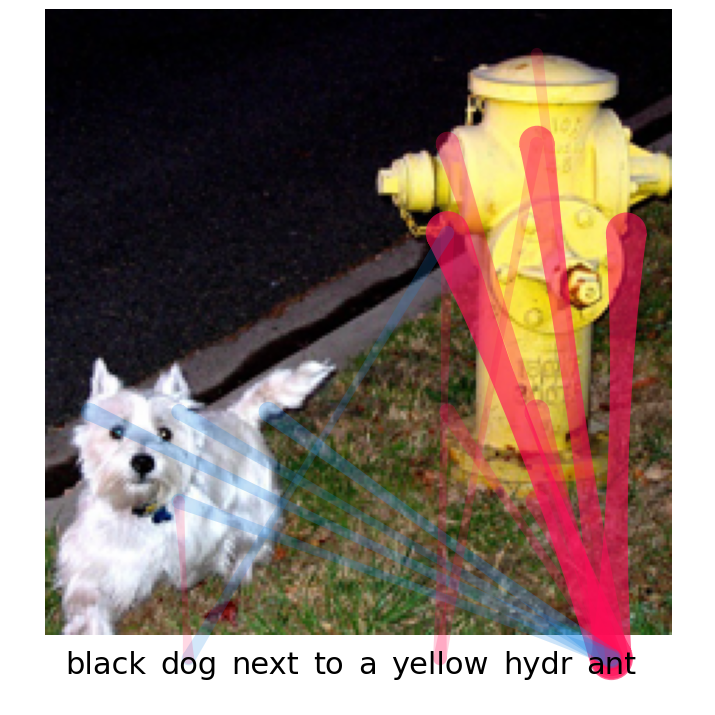

In [21]:
src.plot.plot_image_and_text_together(
    img=input_image_denormalized,
    text=text_tokens,
    image_players=list(range(n_players_image)),
    iv=iv_exclip,
    plot_interactions=True,
    top_k=16,
    normalize_jointly=True,
    figsize=(7, 7),
    fontsize=22,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    max_value=0.01,
    show=False,
)
plt.tight_layout(pad=0.15)
# plt.savefig("dog_and_hydrant_exclip.pdf")

### FIxLIP (SLIC)


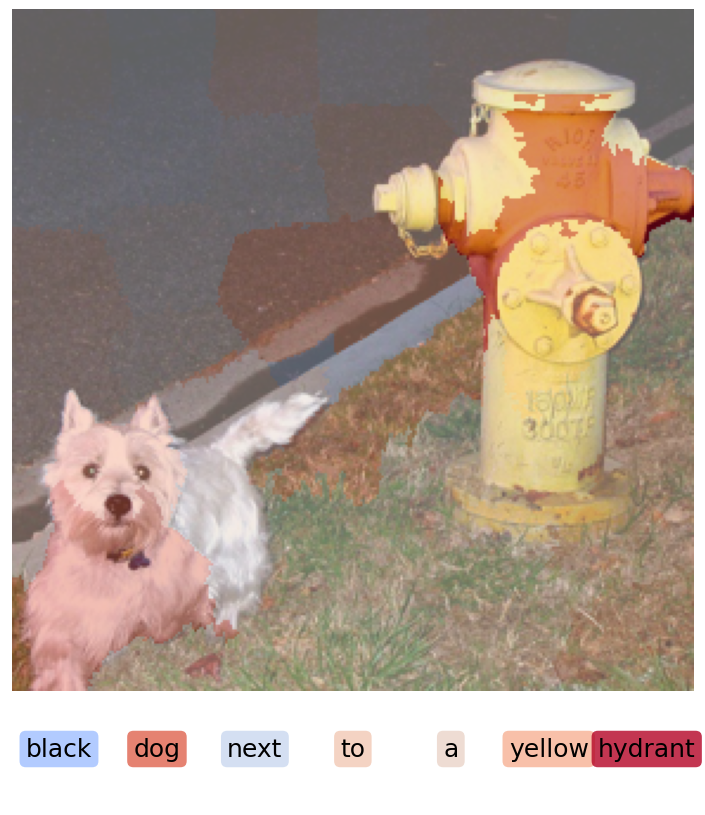

In [60]:
# SLIC visualization replacement for CLIP-ResNet + segmenter="slic"
first_order = src.utils.convert_iv_to_first_order(interaction_values)
values = first_order.get_n_order(1).values
image_values = values[:game.n_players_image]
text_values = values[game.n_players_image:game.n_players_image + len(text_tokens)]
label_map = game._imputer.segmenter._label_map.cpu().numpy()
superpixel_heatmap = image_values[label_map]
max_abs_image = np.quantile(np.abs(image_values), 0.99)
if max_abs_image == 0 or not np.isfinite(max_abs_image):
    max_abs_image = np.max(np.abs(image_values)) if image_values.size else 1.0
max_abs_text = np.max(np.abs(text_values)) if text_values.size else 1.0
if max_abs_text == 0 or not np.isfinite(max_abs_text):
    max_abs_text = 1.0
cmap = plt.get_cmap("coolwarm")
fig, (ax_img, ax_text) = plt.subplots(
    2,
    1,
    figsize=(7, 8),
    gridspec_kw={"height_ratios": [7, 1.15]},
)
ax_img.imshow(input_image_denormalized)
overlay = ax_img.imshow(
    superpixel_heatmap,
    alpha=0.45,
    cmap="coolwarm",
    vmin=-max_abs_image,
    vmax=max_abs_image,
)
ax_img.axis("off")
ax_text.set_xlim(0, 1)
ax_text.set_ylim(0, 1)
ax_text.axis("off")
n_tokens = max(len(text_tokens), 1)
for i, token in enumerate(text_tokens):
    value = text_values[i] if i < len(text_values) else 0.0
    color = cmap((value / max_abs_text + 1.0) / 2.0)
    x = (i + 0.5) / n_tokens
    ax_text.text(
       x,
       0.5,
       token,
       ha="center",
       va="center",
       fontsize=18,
       bbox={"boxstyle": "round,pad=0.25", "facecolor": color, "edgecolor": "none", "alpha": 0.8},
      )
plt.tight_layout(pad=0.15)
# plt.savefig("dog_and_hydrant_fixlip_slic.pdf")